## RQ 6: Which teams scored goals at home turf most often in 2025?

In [1]:
import requests
import matplotlib.pyplot as plt

In [ ]:
result = [[], [], [], []] 
# [0] teamID, [1] number goals home, [2] number goals away, [3] teamName

# get all matchIDs of season 2025
response = requests.get("https://api.openligadb.de/getmatchdata/bl1/2025")
response = response.json()
matchIDs = []
for match in response:
    matchID = match ['matchID']
    matchIDs.append(matchID)

# get all teamIDs
for matchID in matchIDs:
    # get match 
    url = "https://api.openligadb.de/getmatchdata/"
    url += str(matchID)
    match = requests.get(url)
    match = match.json()

    # get both teams, if new add to result[0]
    teamID1 = match ['team1'] ['teamId']
    teamID2 = match ['team2'] ['teamId']
    if teamID1 not in result[0]:
        result[0] += [teamID1]
        result[1] += [0]
        result[2] += [0]
        result[3] += [match ['team1'] ['teamName']]
    if teamID2 not in result[0]:
        result[0] += [teamID2]
        result[1] += [0]
        result[2] += [0]
        result[3] += [match ['team2'] ['teamName']]
    
    # get all goals in match and team that scored them 
    goals = match ['goals']
    score1 = 0
    score2 = 0
    for goal in goals:
        score1new = goal ['scoreTeam1'] 
        score2new = goal ['scoreTeam2']
        if score1new > score1: 
            # team1 is hometeam
            index = result [0].index(teamID1)
            result [1] [index] += 1
            score1 = score1new
        else:
            index = result [0].index(teamID2)
            result [2] [index] += 1
            score2 = score2new

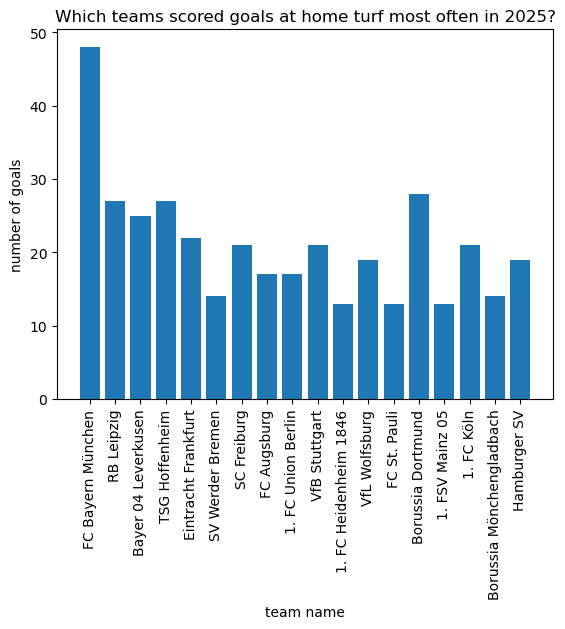

In [3]:
x = result[3]
y = result[1]
plt.bar(x,y)
plt.title('Which teams scored goals at home turf most often in 2025?')
plt.xlabel('team name')
plt.xticks(rotation = 90)
plt.ylabel('number of goals')
plt.show()